# Step 0

In [1]:
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance

In [2]:
seed = 42
np.random.seed(seed)
random.seed(seed)

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", __import__("matplotlib").__version__)
print("Seed:", seed)

Python: 3.11.9 | packaged by Anaconda, Inc. | (main, Apr 19 2024, 16:40:41) [MSC v.1916 64 bit (AMD64)]
NumPy: 1.26.4
Pandas: 2.2.2
Scikit-learn: 1.9.0
Matplotlib: 3.8.4
Seed: 42


In [ ]:
raw = pd.read_csv('../data/Q1/compas-scores-two-years.csv')
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [4]:
df = raw[
        (raw["days_b_screening_arrest"] <= 30) &
        (raw["days_b_screening_arrest"] >= -30) &
        (raw["is_recid"] != -1) &
        (raw["c_charge_degree"] != "O") &
        (raw["score_text"] != "N/A")
    ]

print("After ProPublica filter shape:", df.shape)
print('---------------')
print("Target distribution:")
print(df["two_year_recid"].value_counts(normalize=True).rename("proportion"))
print('---------------')
print("Race distribution:")
print(df["race"].value_counts())
print('---------------')
print("Sex distribution:")
print(df["sex"].value_counts())

After ProPublica filter shape: (6172, 53)
---------------
Target distribution:
two_year_recid
0    0.54488
1    0.45512
Name: proportion, dtype: float64
---------------
Race distribution:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64
---------------
Sex distribution:
sex
Male      4997
Female    1175
Name: count, dtype: int64


In [5]:
features_with_race = ["sex", "age", "race", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count", "c_charge_degree", "decile_score"]

features_without_race = ["sex", "age", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count", "c_charge_degree", "decile_score"]

needed_cols = list(set(features_with_race + ["two_year_recid", "race", "sex"]))
df_model = df[needed_cols].dropna(subset=["two_year_recid", "race", "sex"]).copy()

df_model["two_year_recid"] = df_model["two_year_recid"].astype(int)

print("Modeling shape:", df_model.shape)


Modeling shape: (6172, 10)


In [6]:
train_df, test_df = train_test_split(df_model, test_size=0.3, stratify=df_model['two_year_recid'], random_state=seed)

# Additional validation split from training data for threshold post-processing.
train_fit_df, val_df = train_test_split(train_df, test_size=0.25, stratify=train_df['two_year_recid'], random_state=seed)

print("Train full shape:", train_df.shape)
print("Train-fit shape:", train_fit_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("Train/test ratio:", 0.7, "/", 0.3)
print("Train target rate:", train_df['two_year_recid'].mean())
print("Test target rate:", test_df['two_year_recid'].mean())


Train full shape: (4320, 10)
Train-fit shape: (3240, 10)
Validation shape: (1080, 10)
Test shape: (1852, 10)
Train/test ratio: 0.7 / 0.3
Train target rate: 0.4550925925925926
Test target rate: 0.45518358531317493


In [7]:
print(train_df['two_year_recid'].value_counts())
print(test_df['two_year_recid'].value_counts())

two_year_recid
0    2354
1    1966
Name: count, dtype: int64
two_year_recid
0    1009
1     843
Name: count, dtype: int64


# Step 1

In [8]:
base_rates_by_race = df_model.groupby("race")["two_year_recid"].agg(["count", "mean"]).rename(columns={"mean": "P(Y=1)"}).sort_values("P(Y=1)", ascending=False)
base_rates_by_race

,count,P(Y=1)
race,,
African-American,3175,0.523150
Native American,11,0.454545
Caucasian,2103,0.390870
Hispanic,509,0.371316
Other,343,0.361516
Asian,31,0.258065


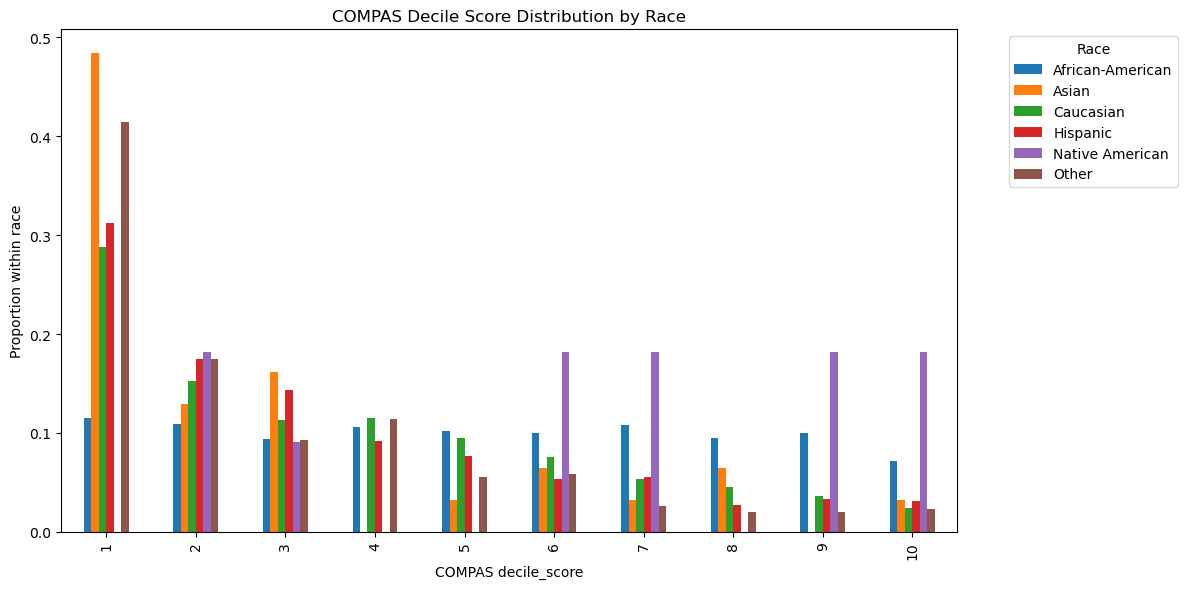

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,0.114961,0.483871,0.287684,0.312377,0.000000,0.413994
2,0.108976,0.129032,0.152639,0.174853,0.181818,0.174927
3,0.093858,0.161290,0.113172,0.143418,0.090909,0.093294
4,0.106142,0.000000,0.115549,0.092338,0.000000,0.113703
5,0.101732,0.032258,0.095102,0.076621,0.000000,0.055394
6,0.100157,0.064516,0.076082,0.053045,0.181818,0.058309
7,0.108031,0.032258,0.053733,0.055010,0.181818,0.026239
8,0.094803,0.064516,0.045649,0.027505,0.000000,0.020408
9,0.099843,0.000000,0.036614,0.033399,0.181818,0.020408


In [9]:
decile_dist = df_model.groupby(["race", "decile_score"]).size().reset_index(name="count")

race_counts = df_model["race"].value_counts()
decile_dist["proportion_within_race"] = decile_dist.apply(lambda row: row["count"] / race_counts.loc[row["race"]], axis=1)

pivot_decile = decile_dist.pivot(index="decile_score", columns="race", values="proportion_within_race").fillna(0)

ax = pivot_decile.plot(kind="bar", figsize=(12, 6))
ax.set_title("COMPAS Decile Score Distribution by Race")
ax.set_xlabel("COMPAS decile_score")
ax.set_ylabel("Proportion within race")
ax.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

pivot_decile

In [10]:
def make_preprocessor(feature_cols, df_reference):
    categorical_cols = [
        c for c in feature_cols
        if df_reference[c].dtype == "object" or str(df_reference[c].dtype).startswith("category")
    ]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols)
        ],
        remainder="drop"
    )

    return preprocessor, numeric_cols, categorical_cols


def get_feature_names_from_preprocessor(preprocessor, numeric_cols, categorical_cols):
    names = []
    names.extend(numeric_cols)

    if len(categorical_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = list(ohe.get_feature_names_out(categorical_cols))
        names.extend(cat_names)

    return names


In [11]:
proxy_features = features_without_race

X_proxy = df_model[proxy_features]
y_race = df_model["race"]

proxy_train_X, proxy_test_X, proxy_train_y, proxy_test_y = train_test_split(X_proxy, y_race, test_size=0.30, stratify=y_race, random_state=seed)

proxy_preprocessor, proxy_num, proxy_cat = make_preprocessor(proxy_features, df_model)

race_proxy_model = Pipeline(steps=[
    ("preprocess", proxy_preprocessor),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=seed))])

race_proxy_model.fit(proxy_train_X, proxy_train_y)
race_pred = race_proxy_model.predict(proxy_test_X)
race_prob = race_proxy_model.predict_proba(proxy_test_X)

proxy_acc = accuracy_score(proxy_test_y, race_pred)

# Multiclass ROC-AUC, if possible.
try:
    proxy_auc = roc_auc_score(proxy_test_y, race_prob, multi_class="ovr", average="macro")
except Exception:
    proxy_auc = np.nan

print("Race-from-non-race proxy model")
print("Accuracy:", proxy_acc)
print("Macro OVR ROC-AUC:", proxy_auc)

pd.DataFrame(
    confusion_matrix(proxy_test_y, race_pred, labels=race_proxy_model.classes_),
    index=[f"true_{c}" for c in race_proxy_model.classes_],
    columns=[f"pred_{c}" for c in race_proxy_model.classes_]
)

Race-from-non-race proxy model
Accuracy: 0.24892008639308855
Macro OVR ROC-AUC: 0.5896643045743685


,pred_African-American,pred_Asian,pred_Caucasian,pred_Hispanic,pred_Native American,pred_Other
true_African-American,270,114,65,82,250,172
true_Asian,0,2,1,1,0,5
true_Caucasian,83,160,131,66,93,98
true_Hispanic,22,28,22,19,19,43
true_Native American,2,0,0,0,0,1
true_Other,8,23,15,9,9,39


In [12]:
perm = permutation_importance(race_proxy_model, proxy_test_X, proxy_test_y, n_repeats=10, random_state=seed, scoring="accuracy")

proxy_importance = pd.DataFrame({
    "feature": proxy_features,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

proxy_importance


,feature,importance_mean,importance_std
7,decile_score,0.069978,0.007694
1,age,0.049298,0.008207
5,priors_count,0.028294,0.003028
6,c_charge_degree,0.022138,0.003508
4,juv_other_count,0.014255,0.002890
0,sex,0.011285,0.003978
3,juv_misd_count,0.002214,0.001573
2,juv_fel_count,-0.000810,0.001660


# Step 2

In [13]:
eps = 1e-12

def binary_confusion_counts(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    return tp, fp, tn, fn


def rates_from_counts(tp, fp, tn, fn):
    n = tp + fp + tn + fn

    ppr = (tp + fp) / max(n, eps)
    base_rate = (tp + fn) / max(n, eps)
    tpr = tp / max(tp + fn, eps)
    fpr = fp / max(fp + tn, eps)
    tnr = tn / max(fp + tn, eps)
    fnr = fn / max(tp + fn, eps)
    ppv = tp / max(tp + fp, eps)
    npv = tn / max(tn + fn, eps)
    acc = (tp + tn) / max(n, eps)

    return {"n": n, "base_rate": base_rate, "selection_rate": ppr, "TPR": tpr, "FPR": fpr, "TNR": tnr, "FNR": fnr, "PPV": ppv, "NPV": npv, "accuracy": acc,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn}


def group_metric_table(y_true, y_pred, sensitive):
    rows = []

    data = pd.DataFrame({
        "y_true": np.asarray(y_true).astype(int),
        "y_pred": np.asarray(y_pred).astype(int),
        "group": np.asarray(sensitive)
    })

    for group_value, sub in data.groupby("group"):
        tp, fp, tn, fn = binary_confusion_counts(sub["y_true"], sub["y_pred"])
        metrics = rates_from_counts(tp, fp, tn, fn)
        metrics["group"] = group_value
        rows.append(metrics)

    out = pd.DataFrame(rows)
    cols = ["group", "n", "base_rate", "selection_rate", "TPR", "FPR", "TNR", "FNR", "PPV", "NPV", "accuracy", "TP", "FP", "TN", "FN"]
    return out[cols].sort_values("group").reset_index(drop=True)


def between_group_gaps(group_table):
    def gap(col):
        vals = group_table[col].dropna()
        if len(vals) == 0:
            return np.nan
        return float(vals.max() - vals.min())

    return {
        "demographic_parity_difference": gap("selection_rate"),
        "equal_opportunity_difference_TPR_gap": gap("TPR"),
        "false_positive_rate_parity_difference": gap("FPR"),
        "PPV_gap": gap("PPV"),
        "base_rate_gap": gap("base_rate")
    }


def overall_metrics(y_true, y_pred, y_score=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)

    if y_score is not None:
        try:
            out["ROC_AUC"] = roc_auc_score(y_true, y_score)
        except Exception:
            out["ROC_AUC"] = np.nan
    else:
        out["ROC_AUC"] = np.nan

    tp, fp, tn, fn = binary_confusion_counts(y_true, y_pred)
    out.update(rates_from_counts(tp, fp, tn, fn))
    return out


def evaluate_model_outputs(name, y_true, y_pred, y_score, sensitive):
    overall = overall_metrics(y_true, y_pred, y_score)
    overall["model"] = name

    group_table = group_metric_table(y_true, y_pred, sensitive)
    group_table.insert(0, "model", name)

    gaps = between_group_gaps(group_table)
    gaps["model"] = name

    return pd.DataFrame([overall]), group_table, pd.DataFrame([gaps])


In [14]:
def make_logistic_pipeline(feature_cols, df_reference):
    preprocessor, num_cols, cat_cols = make_preprocessor(feature_cols, df_reference)

    clf = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight=None, random_state=seed)

    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("clf", clf)
    ])

    return pipe


baseline_with_race = make_logistic_pipeline(features_with_race, train_df)

X_train = train_df[features_with_race]
y_train = train_df["two_year_recid"].astype(int)

X_test = test_df[features_with_race]
y_test = test_df["two_year_recid"].astype(int)
race_test = test_df["race"]

baseline_with_race.fit(X_train, y_train)

score_baseline = baseline_with_race.predict_proba(X_test)[:, 1]
pred_baseline = (score_baseline >= 0.5).astype(int)

overall_baseline, group_baseline, gaps_baseline = evaluate_model_outputs("baseline_with_race", y_test, pred_baseline, score_baseline, race_test)

display(overall_baseline)
display(group_baseline)
display(gaps_baseline)


,accuracy,ROC_AUC,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,TP,FP,TN,FN,model
0,0.687365,0.741306,1852,0.455184,0.36933,0.562278,0.208127,0.791873,0.437722,0.692982,0.684075,474,210,799,369,baseline_with_race


,model,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,baseline_with_race,African-American,956,0.534519,0.493724,0.665362,0.296629,0.703371,0.334638,0.720339,0.646694,0.683054,340,132,313,171
1,baseline_with_race,Asian,11,0.272727,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.727273,0.727273,0,0,8,3
2,baseline_with_race,Caucasian,645,0.372093,0.254264,0.420833,0.155556,0.844444,0.579167,0.615854,0.711019,0.686822,101,63,342,139
3,baseline_with_race,Hispanic,141,0.425532,0.191489,0.316667,0.098765,0.901235,0.683333,0.703704,0.640351,0.652482,19,8,73,41
4,baseline_with_race,Native American,2,0.000000,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,1.000000,0.500000,0,1,1,0
5,baseline_with_race,Other,97,0.298969,0.206186,0.482759,0.088235,0.911765,0.517241,0.700000,0.805195,0.783505,14,6,62,15


,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,model
0,0.5,0.665362,0.5,0.720339,0.534519,baseline_with_race


# Step 3

In [15]:
baseline_without_race = make_logistic_pipeline(features_without_race, train_df)

X_train_no_race = train_df[features_without_race]
X_test_no_race = test_df[features_without_race]

baseline_without_race.fit(X_train_no_race, y_train)

score_no_race = baseline_without_race.predict_proba(X_test_no_race)[:, 1]
pred_no_race = (score_no_race >= 0.5).astype(int)

overall_no_race, group_no_race, gaps_no_race = evaluate_model_outputs("fairness_through_unawareness_no_race", y_test, pred_no_race, score_no_race, race_test)

display(overall_no_race)
display(group_no_race)
display(gaps_no_race)

,accuracy,ROC_AUC,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,TP,FP,TN,FN,model
0,0.687365,0.743579,1852,0.455184,0.365011,0.557533,0.204163,0.795837,0.442467,0.695266,0.682823,470,206,803,373,fairness_through_unawareness_no_race


,model,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,fairness_through_unawareness_no_race,African-American,956,0.534519,0.495816,0.665362,0.301124,0.698876,0.334638,0.717300,0.645228,0.680962,340,134,311,171
1,fairness_through_unawareness_no_race,Asian,11,0.272727,0.181818,0.666667,0.000000,1.000000,0.333333,1.000000,0.888889,0.909091,2,0,8,1
2,fairness_through_unawareness_no_race,Caucasian,645,0.372093,0.227907,0.383333,0.135802,0.864198,0.616667,0.625850,0.702811,0.685271,92,55,350,148
3,fairness_through_unawareness_no_race,Hispanic,141,0.425532,0.255319,0.416667,0.135802,0.864198,0.583333,0.694444,0.666667,0.673759,25,11,70,35
4,fairness_through_unawareness_no_race,Native American,2,0.000000,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,1.000000,0.500000,0,1,1,0
5,fairness_through_unawareness_no_race,Other,97,0.298969,0.164948,0.379310,0.073529,0.926471,0.620690,0.687500,0.777778,0.762887,11,5,63,18


,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,model
0,0.335052,0.666667,0.5,1.0,0.534519,fairness_through_unawareness_no_race


In [16]:
overall_stage3 = pd.concat([overall_baseline, overall_no_race], ignore_index=True)
gaps_stage3 = pd.concat([gaps_baseline, gaps_no_race], ignore_index=True)

display(overall_stage3[["model", "accuracy", "ROC_AUC", "selection_rate", "TPR", "FPR", "PPV"]])
display(gaps_stage3)


,model,accuracy,ROC_AUC,selection_rate,TPR,FPR,PPV
0,baseline_with_race,0.687365,0.741306,0.369330,0.562278,0.208127,0.692982
1,fairness_through_unawareness_no_race,0.687365,0.743579,0.365011,0.557533,0.204163,0.695266


,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,model
0,0.500000,0.665362,0.5,0.720339,0.534519,baseline_with_race
1,0.335052,0.666667,0.5,1.000000,0.534519,fairness_through_unawareness_no_race


# Step 4

In [ ]:
def calders_kamiran_reweighing_weights(y, sensitive):
    y = pd.Series(y).astype(int).reset_index(drop=True)
    a = pd.Series(sensitive).reset_index(drop=True)

    n = len(y)
    weights = np.zeros(n, dtype=float)

    p_y = y.value_counts(normalize=True).to_dict()
    p_a = a.value_counts(normalize=True).to_dict()

    joint = pd.DataFrame({"a": a, "y": y}).value_counts(normalize=True).to_dict()

    for i in range(n):
        ai = a.iloc[i]
        yi = y.iloc[i]
        p_joint = joint.get((ai, yi), eps)
        weights[i] = (p_a[ai] * p_y[yi]) / max(p_joint, eps)

    return weights


rw_weights = calders_kamiran_reweighing_weights(
    train_df["two_year_recid"],
    train_df["race"]
)

print("Reweighing weights summary:")
pd.Series(rw_weights).describe()

Reweighing weights summary:


count    4320.000000
mean        1.000000
std         0.137716
min         0.726543
25%         0.878131
50%         0.906935
75%         1.131103
max         1.820370
dtype: float64

In [18]:
reweighed_model = make_logistic_pipeline(features_with_race, train_df)

reweighed_model.fit(
    train_df[features_with_race],
    train_df["two_year_recid"].astype(int),
    clf__sample_weight=rw_weights
)

score_rw = reweighed_model.predict_proba(test_df[features_with_race])[:, 1]
pred_rw = (score_rw >= 0.5).astype(int)

overall_rw, group_rw, gaps_rw = evaluate_model_outputs("preprocessing_reweighing_Calders_Kamiran", y_test, pred_rw, score_rw, race_test)

display(overall_rw)
display(group_rw)
display(gaps_rw)



,accuracy,ROC_AUC,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,TP,FP,TN,FN,model
0,0.671706,0.7287,1852,0.455184,0.37311,0.549229,0.225966,0.774034,0.450771,0.670043,0.672696,463,228,781,380,preprocessing_reweighing_Calders_Kamiran


,model,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,preprocessing_reweighing_Calders_Kamiran,African-American,956,0.534519,0.410042,0.571429,0.224719,0.775281,0.428571,0.744898,0.611702,0.666318,292,100,345,219
1,preprocessing_reweighing_Calders_Kamiran,Asian,11,0.272727,0.272727,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,3,0,8,0
2,preprocessing_reweighing_Calders_Kamiran,Caucasian,645,0.372093,0.345736,0.512500,0.246914,0.753086,0.487500,0.551570,0.722749,0.663566,123,100,305,117
3,preprocessing_reweighing_Calders_Kamiran,Hispanic,141,0.425532,0.319149,0.466667,0.209877,0.790123,0.533333,0.622222,0.666667,0.652482,28,17,64,32
4,preprocessing_reweighing_Calders_Kamiran,Native American,2,0.000000,0.500000,0.000000,0.500000,0.500000,0.000000,0.000000,1.000000,0.500000,0,1,1,0
5,preprocessing_reweighing_Calders_Kamiran,Other,97,0.298969,0.278351,0.586207,0.147059,0.852941,0.413793,0.629630,0.828571,0.773196,17,10,58,12


,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,model
0,0.227273,1.0,0.5,1.0,0.534519,preprocessing_reweighing_Calders_Kamiran


In [19]:
def metrics_at_thresholds_by_group(y_true, scores, sensitive, thresholds_by_group):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)
    sensitive = np.asarray(sensitive)

    y_pred = np.zeros_like(y_true, dtype=int)

    for g in np.unique(sensitive):
        t = thresholds_by_group.get(g, 0.5)
        idx = sensitive == g
        y_pred[idx] = (scores[idx] >= t).astype(int)

    return y_pred


def find_group_threshold_for_target_tpr(y_true_g, scores_g, candidate_thresholds, target_tpr):
    best = None

    for t in candidate_thresholds:
        pred = (scores_g >= t).astype(int)
        tp, fp, tn, fn = binary_confusion_counts(y_true_g, pred)
        rates = rates_from_counts(tp, fp, tn, fn)
        dist = abs(rates["TPR"] - target_tpr)

        if best is None or dist < best["dist"]:
            best = {
                "threshold": float(t),
                "TPR": rates["TPR"],
                "FPR": rates["FPR"],
                "selection_rate": rates["selection_rate"],
                "accuracy": rates["accuracy"],
                "dist": dist
            }

    return best


def optimize_equal_opportunity_thresholds(y_val, scores_val, sensitive_val, candidate_thresholds=np.linspace(0.05, 0.95, 19), target_tprs=np.linspace(0.05, 0.95, 19), fairness_weight=1.0, accuracy_weight=0.05):
    y_val = np.asarray(y_val).astype(int)
    scores_val = np.asarray(scores_val)
    sensitive_val = np.asarray(sensitive_val)

    groups = np.unique(sensitive_val)

    best_solution = None

    for target in target_tprs:
        thresholds = {}

        for g in groups:
            idx = sensitive_val == g
            chosen = find_group_threshold_for_target_tpr(y_val[idx], scores_val[idx], candidate_thresholds, target)
            thresholds[g] = chosen["threshold"]

        pred_val = metrics_at_thresholds_by_group(y_val, scores_val, sensitive_val, thresholds)

        group_tbl = group_metric_table(y_val, pred_val, sensitive_val)
        gaps = between_group_gaps(group_tbl)
        acc = accuracy_score(y_val, pred_val)

        obj = fairness_weight * gaps["equal_opportunity_difference_TPR_gap"] - accuracy_weight * acc

        candidate = {
            "target_tpr": target,
            "thresholds": thresholds,
            "accuracy": acc,
            "TPR_gap": gaps["equal_opportunity_difference_TPR_gap"],
            "FPR_gap": gaps["false_positive_rate_parity_difference"],
            "DP_gap": gaps["demographic_parity_difference"],
            "PPV_gap": gaps["PPV_gap"],
            "objective": obj
        }

        if best_solution is None or candidate["objective"] < best_solution["objective"]:
            best_solution = candidate

    return best_solution


In [20]:
post_base_model = make_logistic_pipeline(features_with_race, train_fit_df)

post_base_model.fit(train_fit_df[features_with_race], train_fit_df["two_year_recid"].astype(int))

val_scores = post_base_model.predict_proba(val_df[features_with_race])[:, 1]
val_y = val_df["two_year_recid"].astype(int).values
val_race = val_df["race"].values

eo_solution = optimize_equal_opportunity_thresholds(val_y, val_scores, val_race)

print("Chosen equal-opportunity solution:")
print(json.dumps(
    {
        "target_tpr": float(eo_solution["target_tpr"]),
        "accuracy_val": float(eo_solution["accuracy"]),
        "TPR_gap_val": float(eo_solution["TPR_gap"]),
        "thresholds": {str(k): float(v) for k, v in eo_solution["thresholds"].items()}
    },
    indent=2
))

test_scores_post = post_base_model.predict_proba(test_df[features_with_race])[:, 1]
pred_post_eo = metrics_at_thresholds_by_group(y_test, test_scores_post, race_test, eo_solution["thresholds"])

overall_post_eo, group_post_eo, gaps_post_eo = evaluate_model_outputs("postprocessing_group_thresholds_equal_opportunity", y_test, pred_post_eo, test_scores_post, race_test)

display(overall_post_eo)
display(group_post_eo)
display(gaps_post_eo)


Chosen equal-opportunity solution:
{
  "target_tpr": 0.05,
  "accuracy_val": 0.5601851851851852,
  "TPR_gap_val": 0.05228758169934641,
  "thresholds": {
    "African-American": 0.9,
    "Asian": 0.44999999999999996,
    "Caucasian": 0.85,
    "Hispanic": 0.5499999999999999,
    "Native American": 0.9,
    "Other": 0.65
  }
}


,accuracy,ROC_AUC,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,TP,FP,TN,FN,model
0,0.568035,0.739574,1852,0.455184,0.036177,0.065243,0.011893,0.988107,0.934757,0.820896,0.558543,55,12,997,788,postprocessing_group_thresholds_equal_opportunity


,model,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,postprocessing_group_thresholds_equal_opportunity,African-American,956,0.534519,0.033473,0.054795,0.008989,0.991011,0.945205,0.875000,0.477273,0.490586,28,4,441,483
1,postprocessing_group_thresholds_equal_opportunity,Asian,11,0.272727,0.181818,0.666667,0.000000,1.000000,0.333333,1.000000,0.888889,0.909091,2,0,8,1
2,postprocessing_group_thresholds_equal_opportunity,Caucasian,645,0.372093,0.010853,0.016667,0.007407,0.992593,0.983333,0.571429,0.630094,0.629457,4,3,402,236
3,postprocessing_group_thresholds_equal_opportunity,Hispanic,141,0.425532,0.120567,0.216667,0.049383,0.950617,0.783333,0.764706,0.620968,0.638298,13,4,77,47
4,postprocessing_group_thresholds_equal_opportunity,Native American,2,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0,0,2,0
5,postprocessing_group_thresholds_equal_opportunity,Other,97,0.298969,0.092784,0.275862,0.014706,0.985294,0.724138,0.888889,0.761364,0.773196,8,1,67,21


,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,model
0,0.181818,0.666667,0.049383,1.0,0.534519,postprocessing_group_thresholds_equal_opportunity


In [21]:
overall_all = pd.concat([overall_baseline, overall_no_race, overall_rw, overall_post_eo], ignore_index=True)

gaps_all = pd.concat([gaps_baseline, gaps_no_race, gaps_rw, gaps_post_eo], ignore_index=True)

comparison = overall_all[["model", "accuracy", "ROC_AUC"]].merge(gaps_all, on="model", how="left")

comparison = comparison[["model", "accuracy", "ROC_AUC", "demographic_parity_difference", "equal_opportunity_difference_TPR_gap", "false_positive_rate_parity_difference", "PPV_gap", "base_rate_gap"]]

comparison


,model,accuracy,ROC_AUC,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap
0,baseline_with_race,0.687365,0.741306,0.500000,0.665362,0.500000,0.720339,0.534519
1,fairness_through_unawareness_no_race,0.687365,0.743579,0.335052,0.666667,0.500000,1.000000,0.534519
2,preprocessing_reweighing_Calders_Kamiran,0.671706,0.728700,0.227273,1.000000,0.500000,1.000000,0.534519
3,postprocessing_group_thresholds_equal_opportunity,0.568035,0.739574,0.181818,0.666667,0.049383,1.000000,0.534519


# Step 5

In [22]:
thresholds = np.linspace(0.0, 1.0, 11)

sweep_rows = []

for t in thresholds:
    pred_t = (score_baseline >= t).astype(int)

    overall_t = overall_metrics(y_test, pred_t, score_baseline)
    group_t = group_metric_table(y_test, pred_t, race_test)
    gaps_t = between_group_gaps(group_t)

    row = {"threshold": t, "accuracy": overall_t["accuracy"], "ROC_AUC": overall_t["ROC_AUC"], **gaps_t}
    sweep_rows.append(row)

threshold_sweep = pd.DataFrame(sweep_rows)
threshold_sweep


,threshold,accuracy,ROC_AUC,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap
0,0.0,0.455184,0.741306,0.000000,1.000000,0.000000,0.534519,0.534519
1,0.1,0.458963,0.741306,0.181818,1.000000,0.250000,0.534519,0.534519
2,0.2,0.524838,0.741306,0.636364,1.000000,0.875000,0.750000,0.534519
3,0.3,0.621490,0.741306,0.727273,1.000000,1.000000,1.000000,0.534519
4,0.4,0.666847,0.741306,0.818182,0.810176,1.000000,1.000000,0.534519
5,0.5,0.687365,0.741306,0.500000,0.665362,0.500000,0.720339,0.534519
6,0.6,0.671706,0.741306,0.346234,0.504892,0.164045,0.888889,0.534519
7,0.7,0.638769,0.741306,0.218619,0.346380,0.071910,0.875000,0.534519
8,0.8,0.592873,0.741306,0.122385,0.187867,0.047191,1.000000,0.534519
9,0.9,0.559935,0.741306,0.036611,0.068966,0.013483,1.000000,0.534519


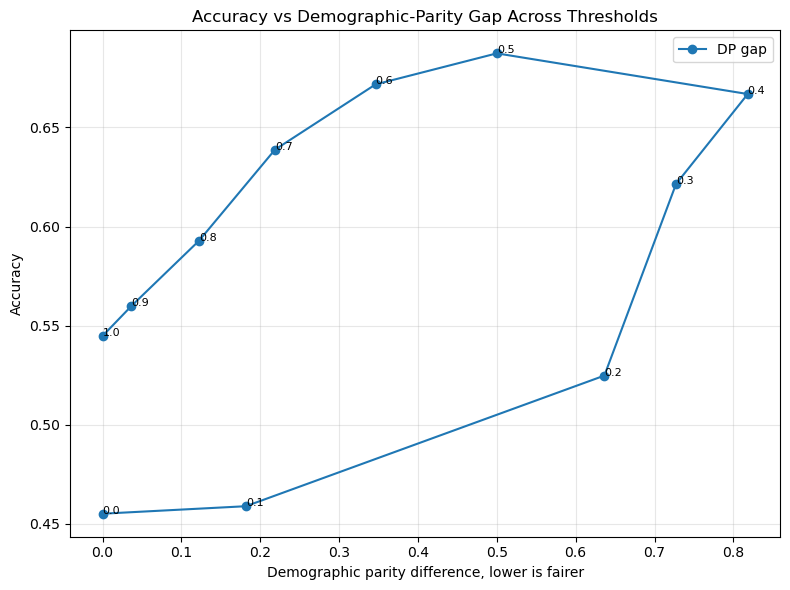

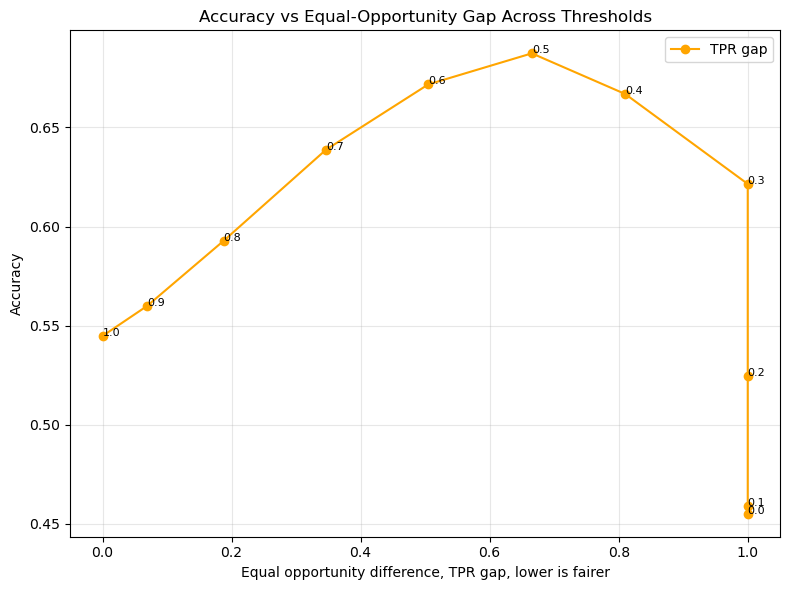

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(threshold_sweep["demographic_parity_difference"], threshold_sweep["accuracy"], marker="o", label="DP gap")

for _, row in threshold_sweep.iterrows():
    plt.text(row["demographic_parity_difference"], row["accuracy"], f"{row['threshold']:.1f}", fontsize=8)

plt.xlabel("Demographic parity difference, lower is fairer")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Demographic-Parity Gap Across Thresholds")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(threshold_sweep["equal_opportunity_difference_TPR_gap"], threshold_sweep["accuracy"], marker="o", color="orange", label="TPR gap")

for _, row in threshold_sweep.iterrows():
    plt.text(row["equal_opportunity_difference_TPR_gap"], row["accuracy"], f"{row['threshold']:.1f}", fontsize=8)

plt.xlabel("Equal opportunity difference, TPR gap, lower is fairer")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Equal-Opportunity Gap Across Thresholds")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def pareto_frontier_accuracy_fairness(df_tradeoff, fairness_col, accuracy_col="accuracy"):
    points = df_tradeoff.copy().sort_values([fairness_col, accuracy_col], ascending=[True, False])

    frontier_rows = []
    best_acc_so_far = -np.inf

    for _, row in points.iterrows():
        if row[accuracy_col] > best_acc_so_far + 1e-12:
            frontier_rows.append(row)
            best_acc_so_far = row[accuracy_col]

    return pd.DataFrame(frontier_rows)

pareto_dp = pareto_frontier_accuracy_fairness(threshold_sweep,"demographic_parity_difference")

pareto_tpr = pareto_frontier_accuracy_fairness(threshold_sweep, "equal_opportunity_difference_TPR_gap")

display(pareto_dp)
display(pareto_tpr)


,threshold,accuracy,ROC_AUC,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap
10,1.0,0.544816,0.741306,0.000000,0.000000,0.000000,0.000000,0.534519
9,0.9,0.559935,0.741306,0.036611,0.068966,0.013483,1.000000,0.534519
8,0.8,0.592873,0.741306,0.122385,0.187867,0.047191,1.000000,0.534519
7,0.7,0.638769,0.741306,0.218619,0.346380,0.071910,0.875000,0.534519
6,0.6,0.671706,0.741306,0.346234,0.504892,0.164045,0.888889,0.534519
5,0.5,0.687365,0.741306,0.500000,0.665362,0.500000,0.720339,0.534519


,threshold,accuracy,ROC_AUC,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap
10,1.0,0.544816,0.741306,0.000000,0.000000,0.000000,0.000000,0.534519
9,0.9,0.559935,0.741306,0.036611,0.068966,0.013483,1.000000,0.534519
8,0.8,0.592873,0.741306,0.122385,0.187867,0.047191,1.000000,0.534519
7,0.7,0.638769,0.741306,0.218619,0.346380,0.071910,0.875000,0.534519
6,0.6,0.671706,0.741306,0.346234,0.504892,0.164045,0.888889,0.534519
5,0.5,0.687365,0.741306,0.500000,0.665362,0.500000,0.720339,0.534519


In [25]:
impossibility_table = comparison[["model", "accuracy", "demographic_parity_difference", "equal_opportunity_difference_TPR_gap", "false_positive_rate_parity_difference", "PPV_gap", "base_rate_gap"]].copy()

tol = 1e-3

impossibility_table["all_DP_TPR_PPV_zero_with_tol"] = (
    (impossibility_table["demographic_parity_difference"].abs() <= tol) &
    (impossibility_table["equal_opportunity_difference_TPR_gap"].abs() <= tol) &
    (impossibility_table["PPV_gap"].abs() <= tol)
)

impossibility_table


,model,accuracy,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,all_DP_TPR_PPV_zero_with_tol
0,baseline_with_race,0.687365,0.500000,0.665362,0.500000,0.720339,0.534519,False
1,fairness_through_unawareness_no_race,0.687365,0.335052,0.666667,0.500000,1.000000,0.534519,False
2,preprocessing_reweighing_Calders_Kamiran,0.671706,0.227273,1.000000,0.500000,1.000000,0.534519,False
3,postprocessing_group_thresholds_equal_opportunity,0.568035,0.181818,0.666667,0.049383,1.000000,0.534519,False


In [26]:
def ppv_identity_residual_table(y_true, y_pred, sensitive, model_name):
    tbl = group_metric_table(y_true, y_pred, sensitive).copy()

    denom = tbl["base_rate"] * tbl["TPR"] + (1 - tbl["base_rate"]) * tbl["FPR"]
    tbl["PPV_from_identity"] = np.where(denom.abs() > eps, (tbl["base_rate"] * tbl["TPR"]) / denom, np.nan)

    tbl["PPV_identity_residual"] = tbl["PPV"] - tbl["PPV_from_identity"]
    tbl["abs_residual"] = tbl["PPV_identity_residual"].abs()
    tbl.insert(0, "model", model_name)

    return tbl[["model", "group", "n", "base_rate", "FPR", "FNR", "TPR", "PPV", "PPV_from_identity", "PPV_identity_residual", "abs_residual"]]

resid_baseline = ppv_identity_residual_table(y_test, pred_baseline, race_test, "baseline_with_race")

resid_no_race = ppv_identity_residual_table(y_test, pred_no_race, race_test, "fairness_through_unawareness_no_race")

resid_rw = ppv_identity_residual_table(y_test, pred_rw, race_test, "preprocessing_reweighing_Calders_Kamiran")

resid_post_eo = ppv_identity_residual_table(y_test, pred_post_eo, race_test, "postprocessing_group_thresholds_equal_opportunity")

identity_residuals = pd.concat([resid_baseline, resid_no_race, resid_rw, resid_post_eo], ignore_index=True)

display(identity_residuals)

print("Maximum absolute residual:", identity_residuals["abs_residual"].max())


,model,group,n,base_rate,FPR,FNR,TPR,PPV,PPV_from_identity,PPV_identity_residual,abs_residual
0,baseline_with_race,African-American,956,0.534519,0.296629,0.334638,0.665362,0.720339,0.720339,0.000000e+00,0.000000e+00
1,baseline_with_race,Asian,11,0.272727,0.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN
2,baseline_with_race,Caucasian,645,0.372093,0.155556,0.579167,0.420833,0.615854,0.615854,-1.110223e-16,1.110223e-16
3,baseline_with_race,Hispanic,141,0.425532,0.098765,0.683333,0.316667,0.703704,0.703704,0.000000e+00,0.000000e+00
4,baseline_with_race,Native American,2,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
5,baseline_with_race,Other,97,0.298969,0.088235,0.517241,0.482759,0.700000,0.700000,-1.110223e-16,1.110223e-16
6,fairness_through_unawareness_no_race,African-American,956,0.534519,0.301124,0.334638,0.665362,0.717300,0.717300,0.000000e+00,0.000000e+00
7,fairness_through_unawareness_no_race,Asian,11,0.272727,0.000000,0.333333,0.666667,1.000000,1.000000,0.000000e+00,0.000000e+00
8,fairness_through_unawareness_no_race,Caucasian,645,0.372093,0.135802,0.616667,0.383333,0.625850,0.625850,0.000000e+00,0.000000e+00
9,fairness_through_unawareness_no_race,Hispanic,141,0.425532,0.135802,0.583333,0.416667,0.694444,0.694444,0.000000e+00,0.000000e+00


Maximum absolute residual: 1.1102230246251565e-16


# Step 6

In [27]:
selection_table = comparison.copy()

selection_table["selection_objective"] = (
    selection_table["equal_opportunity_difference_TPR_gap"]
    + 0.5 * selection_table["demographic_parity_difference"]
    - 0.1 * selection_table["accuracy"]
)

selection_table = selection_table.sort_values("selection_objective", ascending=True)
selection_table


,model,accuracy,ROC_AUC,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap,selection_objective
3,postprocessing_group_thresholds_equal_opportunity,0.568035,0.739574,0.181818,0.666667,0.049383,1.000000,0.534519,0.700772
1,fairness_through_unawareness_no_race,0.687365,0.743579,0.335052,0.666667,0.500000,1.000000,0.534519,0.765456
0,baseline_with_race,0.687365,0.741306,0.500000,0.665362,0.500000,0.720339,0.534519,0.846626
2,preprocessing_reweighing_Calders_Kamiran,0.671706,0.728700,0.227273,1.000000,0.500000,1.000000,0.534519,1.046466


In [28]:
candidate_predictions = {
    "baseline_with_race": {"y_pred": pred_baseline, "y_score": score_baseline},
    "fairness_through_unawareness_no_race": {"y_pred": pred_no_race, "y_score": score_no_race},
    "preprocessing_reweighing_Calders_Kamiran": {"y_pred": pred_rw, "y_score": score_rw},
    "postprocessing_group_thresholds_equal_opportunity": {"y_pred": pred_post_eo, "y_score": test_scores_post}
}

best_model_name = selection_table.iloc[0]["model"]
print("Best model selected:", best_model_name)

best_pred = candidate_predictions[best_model_name]["y_pred"]
best_score = candidate_predictions[best_model_name]["y_score"]


Best model selected: postprocessing_group_thresholds_equal_opportunity


In [29]:
intersectional_group = test_df["race"].astype(str) + " × " + test_df["sex"].astype(str)

intersectional_table = group_metric_table(
    y_test,
    best_pred,
    intersectional_group
)

intersectional_table.insert(0, "model", best_model_name)

intersectional_gaps = between_group_gaps(intersectional_table)

display(intersectional_table)
display(pd.DataFrame([{**{"model": best_model_name}, **intersectional_gaps}]))


,model,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,postprocessing_group_thresholds_equal_opportunity,African-American × Female,174,0.390805,0.017241,0.044118,0.000000,1.000000,0.955882,1.000000,0.619883,0.626437,3,0,106,65
1,postprocessing_group_thresholds_equal_opportunity,African-American × Male,782,0.566496,0.037084,0.056433,0.011799,0.988201,0.943567,0.862069,0.444887,0.460358,25,4,335,418
2,postprocessing_group_thresholds_equal_opportunity,Asian × Male,11,0.272727,0.181818,0.666667,0.000000,1.000000,0.333333,1.000000,0.888889,0.909091,2,0,8,1
3,postprocessing_group_thresholds_equal_opportunity,Caucasian × Female,139,0.330935,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.669065,0.669065,0,0,93,46
4,postprocessing_group_thresholds_equal_opportunity,Caucasian × Male,506,0.383399,0.013834,0.020619,0.009615,0.990385,0.979381,0.571429,0.619238,0.618577,4,3,309,190
5,postprocessing_group_thresholds_equal_opportunity,Hispanic × Female,24,0.458333,0.041667,0.000000,0.076923,0.923077,1.000000,0.000000,0.521739,0.500000,0,1,12,11
6,postprocessing_group_thresholds_equal_opportunity,Hispanic × Male,117,0.418803,0.136752,0.265306,0.044118,0.955882,0.734694,0.812500,0.643564,0.666667,13,3,65,36
7,postprocessing_group_thresholds_equal_opportunity,Native American × Male,2,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0,0,2,0
8,postprocessing_group_thresholds_equal_opportunity,Other × Female,23,0.086957,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.913043,0.913043,0,0,21,2
9,postprocessing_group_thresholds_equal_opportunity,Other × Male,74,0.364865,0.121622,0.296296,0.021277,0.978723,0.703704,0.888889,0.707692,0.729730,8,1,46,19


,model,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap
0,postprocessing_group_thresholds_equal_opportunity,0.181818,0.666667,0.076923,1.0,0.566496


In [30]:
race_table_best = group_metric_table(y_test, best_pred, test_df["race"])

sex_table_best = group_metric_table(y_test, best_pred, test_df["sex"])

race_gaps_best = between_group_gaps(race_table_best)
sex_gaps_best = between_group_gaps(sex_table_best)
intersectional_gaps_best = between_group_gaps(intersectional_table)

marginal_intersectional_compare = pd.DataFrame([
    {"audit_level": "race", **race_gaps_best},
    {"audit_level": "sex", **sex_gaps_best},
    {"audit_level": "race_x_sex", **intersectional_gaps_best},
])

display(race_table_best)
display(sex_table_best)
display(intersectional_table)
display(marginal_intersectional_compare)


,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,African-American,956,0.534519,0.033473,0.054795,0.008989,0.991011,0.945205,0.875000,0.477273,0.490586,28,4,441,483
1,Asian,11,0.272727,0.181818,0.666667,0.000000,1.000000,0.333333,1.000000,0.888889,0.909091,2,0,8,1
2,Caucasian,645,0.372093,0.010853,0.016667,0.007407,0.992593,0.983333,0.571429,0.630094,0.629457,4,3,402,236
3,Hispanic,141,0.425532,0.120567,0.216667,0.049383,0.950617,0.783333,0.764706,0.620968,0.638298,13,4,77,47
4,Native American,2,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0,0,2,0
5,Other,97,0.298969,0.092784,0.275862,0.014706,0.985294,0.724138,0.888889,0.761364,0.773196,8,1,67,21


,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,Female,360,0.352778,0.011111,0.023622,0.004292,0.995708,0.976378,0.750000,0.651685,0.652778,3,1,232,124
1,Male,1492,0.479893,0.042225,0.072626,0.014175,0.985825,0.927374,0.825397,0.535339,0.547587,52,11,765,664


,model,group,n,base_rate,selection_rate,TPR,FPR,TNR,FNR,PPV,NPV,accuracy,TP,FP,TN,FN
0,postprocessing_group_thresholds_equal_opportunity,African-American × Female,174,0.390805,0.017241,0.044118,0.000000,1.000000,0.955882,1.000000,0.619883,0.626437,3,0,106,65
1,postprocessing_group_thresholds_equal_opportunity,African-American × Male,782,0.566496,0.037084,0.056433,0.011799,0.988201,0.943567,0.862069,0.444887,0.460358,25,4,335,418
2,postprocessing_group_thresholds_equal_opportunity,Asian × Male,11,0.272727,0.181818,0.666667,0.000000,1.000000,0.333333,1.000000,0.888889,0.909091,2,0,8,1
3,postprocessing_group_thresholds_equal_opportunity,Caucasian × Female,139,0.330935,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.669065,0.669065,0,0,93,46
4,postprocessing_group_thresholds_equal_opportunity,Caucasian × Male,506,0.383399,0.013834,0.020619,0.009615,0.990385,0.979381,0.571429,0.619238,0.618577,4,3,309,190
5,postprocessing_group_thresholds_equal_opportunity,Hispanic × Female,24,0.458333,0.041667,0.000000,0.076923,0.923077,1.000000,0.000000,0.521739,0.500000,0,1,12,11
6,postprocessing_group_thresholds_equal_opportunity,Hispanic × Male,117,0.418803,0.136752,0.265306,0.044118,0.955882,0.734694,0.812500,0.643564,0.666667,13,3,65,36
7,postprocessing_group_thresholds_equal_opportunity,Native American × Male,2,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0,0,2,0
8,postprocessing_group_thresholds_equal_opportunity,Other × Female,23,0.086957,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.913043,0.913043,0,0,21,2
9,postprocessing_group_thresholds_equal_opportunity,Other × Male,74,0.364865,0.121622,0.296296,0.021277,0.978723,0.703704,0.888889,0.707692,0.729730,8,1,46,19


,audit_level,demographic_parity_difference,equal_opportunity_difference_TPR_gap,false_positive_rate_parity_difference,PPV_gap,base_rate_gap
0,race,0.181818,0.666667,0.049383,1.000000,0.534519
1,sex,0.031114,0.049004,0.009883,0.075397,0.127115
2,race_x_sex,0.181818,0.666667,0.076923,1.000000,0.566496


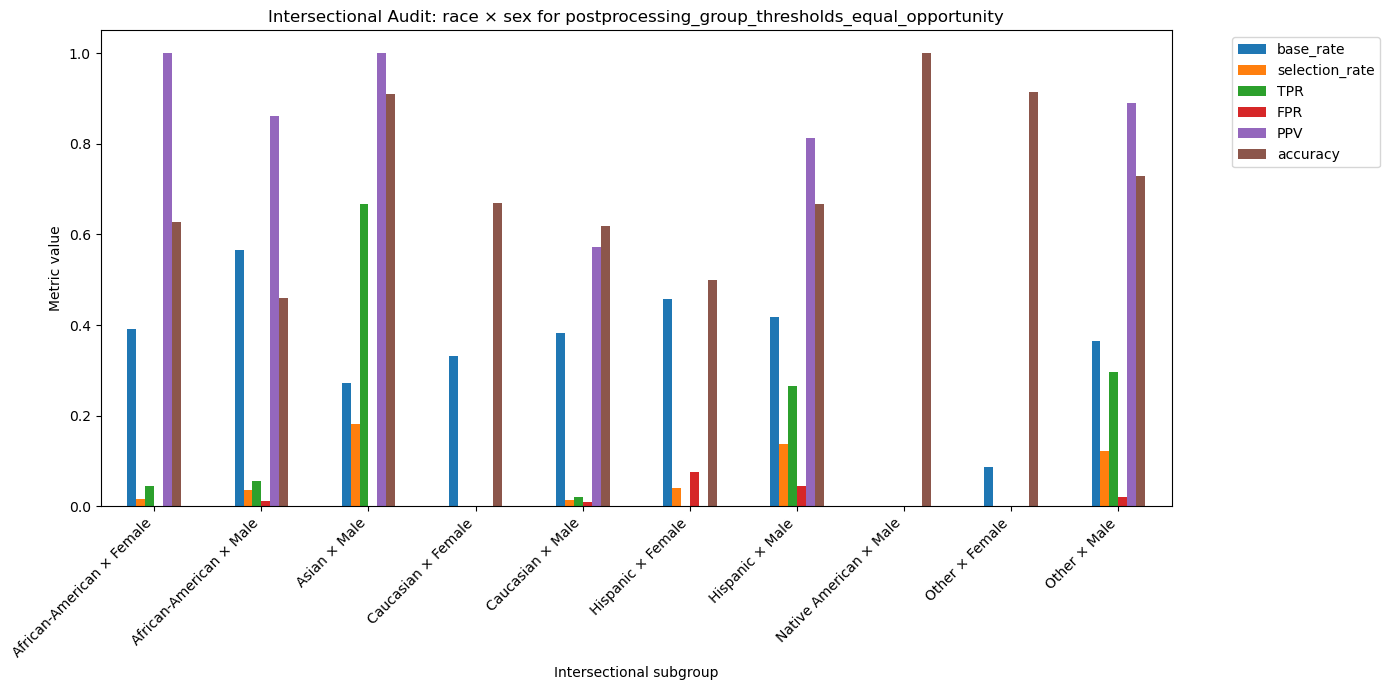

In [31]:
plot_cols = ["base_rate", "selection_rate", "TPR", "FPR", "PPV", "accuracy"]

intersectional_plot = intersectional_table.set_index("group")[plot_cols]

ax = intersectional_plot.plot(kind="bar", figsize=(14, 7))
ax.set_title(f"Intersectional Audit: race × sex for {best_model_name}")
ax.set_xlabel("Intersectional subgroup")
ax.set_ylabel("Metric value")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
